# Multi-Conflict Machine Learning Analysis

This notebook applies machine learning methods to the combined conflict-host panel dataset.

The current version includes two conflict cases:

- Syrian Civil War
- Russia-Ukraine War

The goal is to explore whether refugee exposure, post-conflict period, host-country group, and macroeconomic indicators can help predict host-country GDP growth.

The analysis compares neighboring host countries with non-neighbor major host countries across both conflict cases.

The models are used for exploratory prediction, not for strong causal claims.

In [64]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [65]:
# Define project paths

# This path setup works both when the notebook is run from the project root
# and when it is run from inside the notebooks/ folder.
cwd = Path.cwd()
possible_roots = [cwd, cwd.parent]

REPO_ROOT = None
for root in possible_roots:
    if (root / "data" / "processed").exists():
        REPO_ROOT = root
        break

if REPO_ROOT is None:
    REPO_ROOT = cwd

DATA_PATH = REPO_ROOT / "data" / "processed" / "conflict_host_panel_2010_2024.csv"
FIGURE_DIR = REPO_ROOT / "outputs" / "figures"
TABLE_DIR = REPO_ROOT / "outputs" / "tables"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

print("Working directory:", cwd)
print("Detected repo root:", REPO_ROOT)
print("Looking for data at:", DATA_PATH)
print("File exists:", DATA_PATH.exists())



Working directory: /Users/barisozerdem/Documents/GitHub/DSA210-TermProject/notebooks
Detected repo root: /Users/barisozerdem/Documents/GitHub/DSA210-TermProject
Looking for data at: /Users/barisozerdem/Documents/GitHub/DSA210-TermProject/data/processed/conflict_host_panel_2010_2024.csv
File exists: True


In [66]:
# Load the combined conflict-host panel dataset

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Could not find {DATA_PATH}. Run notebooks/04_multi_conflict_data_collection.ipynb first "
        "and make sure it saves conflict_host_panel_2010_2024.csv under data/processed/."
    )

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
df.head()



Dataset shape: (330, 19)


,conflict_case,origin_name,origin_iso,host_name,host_iso,host_group,year,post_conflict,conflict_intensity,refugee_stock,asylum_seekers,host_population,refugees_per_1000,log_refugee_stock,gdp_growth,inflation,unemployment,trade_pct_gdp,current_account_pct_gdp
0,Syrian Civil War,Syria,SYR,Austria,AUT,non_neighbor_european_host,2010,0,0.0,505.0,471.0,8363404.0,0.060382,6.226537,1.808982,1.813534,4.883,99.644883,2.942949
1,Syrian Civil War,Syria,SYR,Austria,AUT,non_neighbor_european_host,2011,1,1203.0,903.0,456.0,8391643.0,0.107607,6.806829,2.927468,3.286579,4.637,105.775098,1.585010
2,Syrian Civil War,Syria,SYR,Austria,AUT,non_neighbor_european_host,2012,1,50490.0,1675.0,694.0,8429991.0,0.198695,7.424165,0.628246,2.485676,4.909,105.840791,1.510000
3,Syrian Civil War,Syria,SYR,Austria,AUT,non_neighbor_european_host,2013,1,72016.0,2748.0,1561.0,8479823.0,0.324063,7.918992,-0.250726,2.000156,5.367,104.985374,1.752992
4,Syrian Civil War,Syria,SYR,Austria,AUT,non_neighbor_european_host,2014,1,65345.0,6653.0,0.0,8546356.0,0.778460,8.802973,0.755799,1.605812,5.674,104.496740,2.313939


In [67]:
# Basic dataset check

print("Columns:")
print(df.columns.tolist())

print("\nConflict cases:")
print(df["conflict_case"].value_counts())

print("\nHost groups:")
print(df["host_group"].value_counts())

print("\nMissing values:")
print(df.isna().sum())

Columns:
['conflict_case', 'origin_name', 'origin_iso', 'host_name', 'host_iso', 'host_group', 'year', 'post_conflict', 'conflict_intensity', 'refugee_stock', 'asylum_seekers', 'host_population', 'refugees_per_1000', 'log_refugee_stock', 'gdp_growth', 'inflation', 'unemployment', 'trade_pct_gdp', 'current_account_pct_gdp']

Conflict cases:
conflict_case
Russia-Ukraine War    195
Syrian Civil War      135
Name: count, dtype: int64

Host groups:
host_group
non_neighbor_european_host    180
neighboring_host              135
regional_non_neighbor_host     15
Name: count, dtype: int64

Missing values:
conflict_case              0
origin_name                0
origin_iso                 0
host_name                  0
host_iso                   0
host_group                 0
year                       0
post_conflict              0
conflict_intensity         0
refugee_stock              0
asylum_seekers             0
host_population            0
refugees_per_1000          0
log_refugee_stock  

## Feature Selection

The target variable is `gdp_growth`.

The main model uses `post_conflict` instead of `conflict_intensity` because the conflict intensity values are not equally reliable across both conflict cases. In particular, the Ukraine conflict intensity values from the UCDP extract appear lower than expected for 2022 onward, so they are not used as a main feature in this exploratory ML model.

In [68]:
# Select variables for machine learning

target = "gdp_growth"

numeric_features = [
    "post_conflict",
    "refugees_per_1000",
    "log_refugee_stock",
    "inflation",
    "unemployment",
    "trade_pct_gdp",
    "current_account_pct_gdp",
    "year"
]

categorical_features = [
    "conflict_case",
    "host_name",
    "host_group"
]

ml_columns = [target] + numeric_features + categorical_features

ml_df = df[ml_columns].copy()

print("ML dataset shape before cleaning:", ml_df.shape)
ml_df.head()

ML dataset shape before cleaning: (330, 12)


,gdp_growth,post_conflict,refugees_per_1000,log_refugee_stock,inflation,unemployment,trade_pct_gdp,current_account_pct_gdp,year,conflict_case,host_name,host_group
0,1.808982,0,0.060382,6.226537,1.813534,4.883,99.644883,2.942949,2010,Syrian Civil War,Austria,non_neighbor_european_host
1,2.927468,1,0.107607,6.806829,3.286579,4.637,105.775098,1.585010,2011,Syrian Civil War,Austria,non_neighbor_european_host
2,0.628246,1,0.198695,7.424165,2.485676,4.909,105.840791,1.510000,2012,Syrian Civil War,Austria,non_neighbor_european_host
3,-0.250726,1,0.324063,7.918992,2.000156,5.367,104.985374,1.752992,2013,Syrian Civil War,Austria,non_neighbor_european_host
4,0.755799,1,0.778460,8.802973,1.605812,5.674,104.496740,2.313939,2014,Syrian Civil War,Austria,non_neighbor_european_host


In [69]:
# Drop rows with missing values in selected ML columns

ml_df = ml_df.dropna()

print("ML dataset shape after cleaning:", ml_df.shape)

print("\nMissing values after cleaning:")
print(ml_df.isna().sum())

ML dataset shape after cleaning: (329, 12)

Missing values after cleaning:
gdp_growth                 0
post_conflict              0
refugees_per_1000          0
log_refugee_stock          0
inflation                  0
unemployment               0
trade_pct_gdp              0
current_account_pct_gdp    0
year                       0
conflict_case              0
host_name                  0
host_group                 0
dtype: int64


In [70]:
# Quick summary of the usable ML data

print("Usable rows by conflict case:")
print(ml_df["conflict_case"].value_counts())

print("\nUsable rows by host group:")
print(ml_df["host_group"].value_counts())

Usable rows by conflict case:
conflict_case
Russia-Ukraine War    195
Syrian Civil War      134
Name: count, dtype: int64

Usable rows by host group:
host_group
non_neighbor_european_host    180
neighboring_host              134
regional_non_neighbor_host     15
Name: count, dtype: int64


In [71]:
# Define features and target

X = ml_df[numeric_features + categorical_features]
y = ml_df[target]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (329, 11)
Target shape: (329,)


In [72]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (246, 11)
Test set: (83, 11)


In [73]:
# Create preprocessing pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features)
    ]
)

In [74]:
# Define a reusable evaluation function

def evaluate_model(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    return {
        "model": model_name,
        "target": target,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

## Model 1: Linear Regression

Linear Regression is used as a simple baseline model. It helps show whether the selected variables have basic predictive value for GDP growth.

In [75]:
# Train Linear Regression model

linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

linear_results = evaluate_model(
    "Linear Regression",
    y_test,
    linear_predictions
)

linear_results

{'model': 'Linear Regression',
 'target': 'gdp_growth',
 'MAE': 2.018343918454411,
 'RMSE': np.float64(3.1298573266577763),
 'R2': 0.202532598582276}

## Model 2: Decision Tree Regressor

The Decision Tree Regressor is used to test whether a non-linear model can capture additional patterns in the data.

The tree depth is limited to reduce overfitting.

In [76]:
# Train Decision Tree Regressor model

tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeRegressor(
            max_depth=4,
            min_samples_leaf=5,
            random_state=42
        ))
    ]
)

tree_model.fit(X_train, y_train)

tree_predictions = tree_model.predict(X_test)

tree_results = evaluate_model(
    "Decision Tree Regressor",
    y_test,
    tree_predictions
)

tree_results

{'model': 'Decision Tree Regressor',
 'target': 'gdp_growth',
 'MAE': 2.1652461633094933,
 'RMSE': np.float64(3.1858910131353904),
 'R2': 0.17372295603495613}

In [77]:
# Compare model results

results_df = pd.DataFrame([linear_results, tree_results])
results_df

,model,target,MAE,RMSE,R2
0,Linear Regression,gdp_growth,2.018344,3.129857,0.202533
1,Decision Tree Regressor,gdp_growth,2.165246,3.185891,0.173723


In [78]:
# Save model evaluation results

results_path = TABLE_DIR / "multi_conflict_ml_results_gdp_growth.csv"
results_df.to_csv(results_path, index=False)

print("Saved results to:", results_path)

Saved results to: /Users/barisozerdem/Documents/GitHub/DSA210-TermProject/outputs/tables/multi_conflict_ml_results_gdp_growth.csv


## Actual vs Predicted GDP Growth

This plot compares the actual GDP growth values with model predictions.

Points closer to the dashed diagonal line represent better predictions.

In [79]:
# Create actual vs predicted comparison

prediction_df = pd.DataFrame({
    "actual_gdp_growth": y_test.values,
    "linear_prediction": linear_predictions,
    "tree_prediction": tree_predictions
})

prediction_df.head()

,actual_gdp_growth,linear_prediction,tree_prediction
0,1.754976,1.365356,2.082865
1,4.134638,1.701363,2.082865
2,1.303523,1.356854,2.082865
3,7.546471,5.635237,4.622128
4,2.120605,2.365507,2.082865


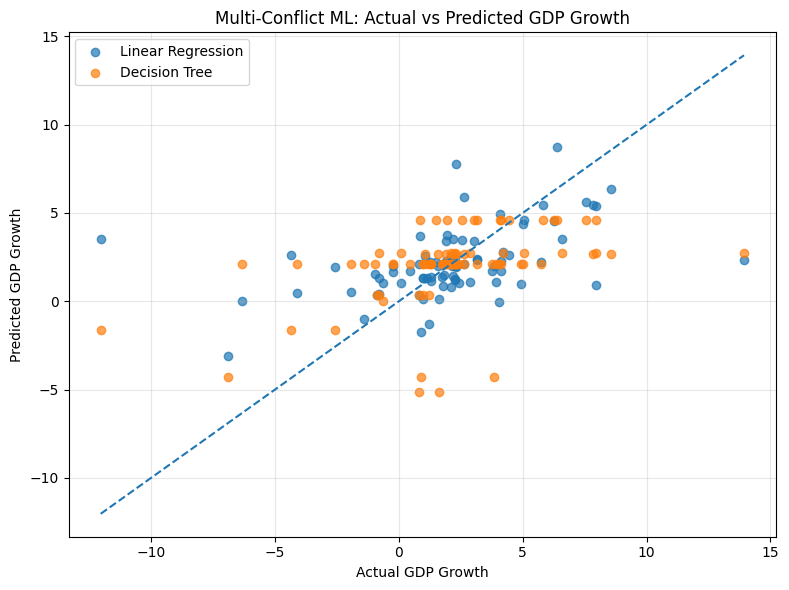

Saved figure to: /Users/barisozerdem/Documents/GitHub/DSA210-TermProject/outputs/figures/multi_conflict_actual_vs_predicted_gdp_growth.png


In [80]:
# Plot actual vs predicted values

plt.figure(figsize=(8, 6))

plt.scatter(
    prediction_df["actual_gdp_growth"],
    prediction_df["linear_prediction"],
    alpha=0.7,
    label="Linear Regression"
)

plt.scatter(
    prediction_df["actual_gdp_growth"],
    prediction_df["tree_prediction"],
    alpha=0.7,
    label="Decision Tree"
)

min_value = min(
    prediction_df["actual_gdp_growth"].min(),
    prediction_df["linear_prediction"].min(),
    prediction_df["tree_prediction"].min()
)

max_value = max(
    prediction_df["actual_gdp_growth"].max(),
    prediction_df["linear_prediction"].max(),
    prediction_df["tree_prediction"].max()
)

plt.plot([min_value, max_value], [min_value, max_value], linestyle="--")

plt.xlabel("Actual GDP Growth")
plt.ylabel("Predicted GDP Growth")
plt.title("Multi-Conflict ML: Actual vs Predicted GDP Growth")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

figure_path = FIGURE_DIR / "multi_conflict_actual_vs_predicted_gdp_growth.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:", figure_path)

## Decision Tree Feature Importance

The feature importance plot shows which variables were most useful for the Decision Tree model.

This should be interpreted carefully because feature importance is model-specific and does not prove causality.

In [81]:
# Get feature names after preprocessing

feature_names = tree_model.named_steps["preprocessor"].get_feature_names_out()
tree_importances = tree_model.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": tree_importances
}).sort_values("importance", ascending=False)

importance_df

,feature,importance
7,num__year,0.313449
1,num__refugees_per_1000,0.255341
26,cat__host_group_non_neighbor_european_host,0.198152
5,num__trade_pct_gdp,0.169381
4,num__unemployment,0.063676
0,num__post_conflict,0.000000
16,cat__host_name_Jordan,0.000000
25,cat__host_name_Turkey,0.000000
24,cat__host_name_Sweden,0.000000
23,cat__host_name_Spain,0.000000


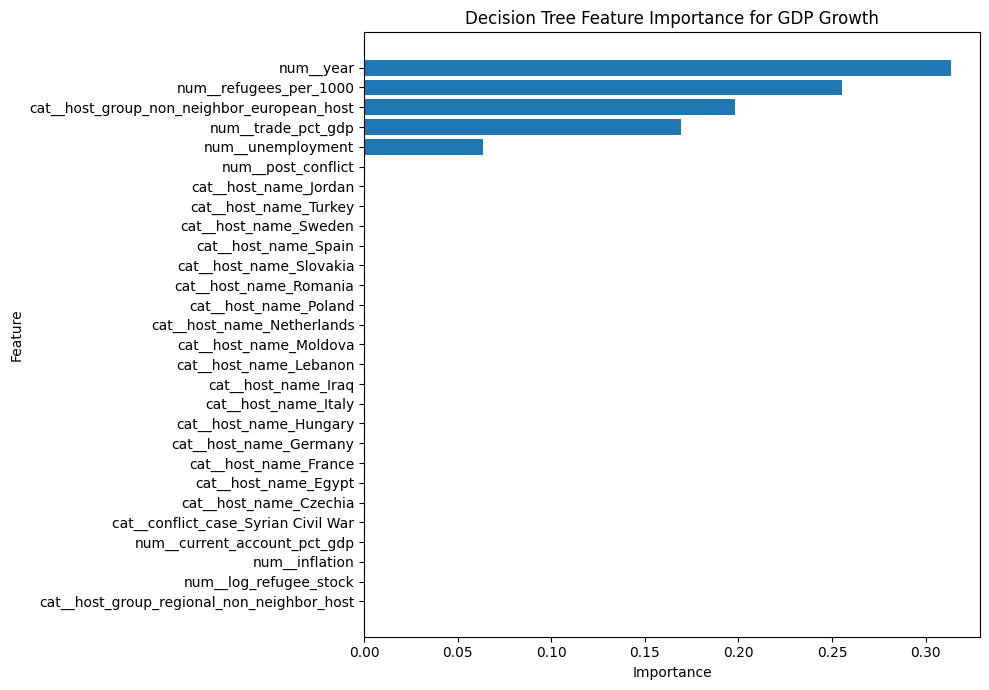

Saved figure to: /Users/barisozerdem/Documents/GitHub/DSA210-TermProject/outputs/figures/multi_conflict_feature_importance_gdp_growth.png


In [82]:
# Plot feature importance

plt.figure(figsize=(10, 7))

plt.barh(importance_df["feature"], importance_df["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Decision Tree Feature Importance for GDP Growth")
plt.gca().invert_yaxis()
plt.tight_layout()

figure_path = FIGURE_DIR / "multi_conflict_feature_importance_gdp_growth.png"
plt.savefig(figure_path, dpi=300)
plt.show()

print("Saved figure to:", figure_path)

## Group-Level Summary

This table summarizes average GDP growth by conflict case, host group, and post-conflict period.

It is not a causal test, but it helps interpret the broader pattern behind the ML models.

In [83]:
# Group-level descriptive summary

group_summary = (
    ml_df
    .groupby(["conflict_case", "host_group", "post_conflict"], as_index=False)
    .agg(
        mean_gdp_growth=("gdp_growth", "mean"),
        median_gdp_growth=("gdp_growth", "median"),
        mean_refugees_per_1000=("refugees_per_1000", "mean"),
        observations=("gdp_growth", "count")
    )
)

group_summary

,conflict_case,host_group,post_conflict,mean_gdp_growth,median_gdp_growth,mean_refugees_per_1000,observations
0,Russia-Ukraine War,neighboring_host,0,3.149989,3.790162,0.004970,60
1,Russia-Ukraine War,neighboring_host,1,1.405953,1.200000,21.666495,15
2,Russia-Ukraine War,non_neighbor_european_host,0,1.314278,1.771318,0.026603,96
3,Russia-Ukraine War,non_neighbor_european_host,1,1.664218,1.211777,9.708932,24
4,Syrian Civil War,neighboring_host,0,6.308683,7.188850,0.012034,4
5,Syrian Civil War,neighboring_host,1,2.454052,2.564791,54.933891,55
6,Syrian Civil War,non_neighbor_european_host,0,3.253426,2.971810,0.096258,4
7,Syrian Civil War,non_neighbor_european_host,1,1.403390,1.762616,4.486076,56
8,Syrian Civil War,regional_non_neighbor_host,0,5.147235,5.147235,0.000090,1
9,Syrian Civil War,regional_non_neighbor_host,1,3.747382,3.655223,1.090814,14


In [84]:
# Save group-level summary

summary_path = TABLE_DIR / "multi_conflict_group_summary.csv"
group_summary.to_csv(summary_path, index=False)

print("Saved group summary to:", summary_path)

Saved group summary to: /Users/barisozerdem/Documents/GitHub/DSA210-TermProject/outputs/tables/multi_conflict_group_summary.csv


## Preliminary ML Interpretation

The multi-conflict ML analysis used 329 usable host-year observations from the Syrian Civil War and the Russia–Ukraine War.

The models were used to predict GDP growth using refugee exposure, post-conflict status, host-country group, conflict case, and macroeconomic indicators.

Linear Regression performed slightly better than the Decision Tree Regressor. It had lower MAE and RMSE and a higher R² score. However, both models explain only a limited part of the variation in GDP growth.

Compared with the earlier Syria-only model, the multi-conflict dataset improved the ML results by increasing the number of observations and adding variation across conflict cases.

Overall, the results should be interpreted as exploratory. They suggest that the selected variables contain some predictive information, but they do not prove a causal relationship between war-related refugee exposure and GDP growth.